# Scenario Comparison
Compares two simulation runs side-by-side across network flows, chokepoint throughput, top-affected routes, and port-level impact.

In [485]:
# ── Scenario configuration ────────────────────────────────────────────────────
SCENARIO_A   = 'scenario_baseline'
SCENARIO_B   = 'scenario_suez_closure_permanent'
LABEL_A      = 'Baseline'
LABEL_B      = 'Strait of Hormuz Closure Scenario'

SIM_ROOT     = '../part_4_new_simulation/simulation_output_data'
NETWORK_FILE = '../part_3_network_extraction/network_outputs/network_calibrated.gpickle'

# How many top edges to draw on the network map (avoids overplotting)
TOP_EDGES_MAP    = 800
# How many edge gainers / losers to show in bar chart
TOP_EDGES_BAR    = 20
# Minimum baseline ship count to include an edge in comparison
MIN_SHIPS        = 5

print(f'Comparing  A: {LABEL_A}  vs  B: {LABEL_B}')

Comparing  A: Baseline  vs  B: Strait of Hormuz Closure Scenario


In [486]:
import pickle, warnings
import numpy as np
import pandas as pd
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.patches import FancyArrowPatch, Patch
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
warnings.filterwarnings('ignore')
import pyarrow.parquet as pq

DIR_A = f'{SIM_ROOT}/{SCENARIO_A}'
DIR_B = f'{SIM_ROOT}/{SCENARIO_B}'

print('Imports OK')

Imports OK


In [487]:
# ── Load network graph ────────────────────────────────────────────────────────
with open(NETWORK_FILE, 'rb') as f:
    G = pickle.load(f)

# Node positions: {str(node_id): (lon, lat)}
# Stored as strings because edge_statistics.parquet serialises all node IDs as strings.
pos = {str(n): (G.nodes[n]['lon'], G.nodes[n]['lat']) for n in G.nodes}

# World basemap (geodatasets replaces deprecated gpd.datasets in GeoPandas 1.0+)
import geodatasets
world = gpd.read_file('https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_countries.zip')

# ── Load simulation outputs ───────────────────────────────────────────────────
edge_a = pd.read_parquet(f'{DIR_A}/edge_statistics.parquet')
edge_b = pd.read_parquet(f'{DIR_B}/edge_statistics.parquet')

choke_a = pd.read_parquet(f'{DIR_A}/choke_cargo.parquet')
choke_b = pd.read_parquet(f'{DIR_B}/choke_cargo.parquet')

port_a = pd.read_parquet(f'{DIR_A}/port_cargo.parquet')
port_b = pd.read_parquet(f'{DIR_B}/port_cargo.parquet')

print(f'Edge rows  A={len(edge_a):,}  B={len(edge_b):,}')
print(f'Choke rows A={len(choke_a):,}  B={len(choke_b):,}')
print(f'Port rows  A={len(port_a):,}  B={len(port_b):,}')

Edge rows  A=14,634  B=14,634
Choke rows A=28  B=28
Port rows  A=588  B=588


In [488]:
# ── Merge edge statistics ─────────────────────────────────────────────────────
# Normalise direction so (min, max) is always the key
for df in (edge_a, edge_b):
    df['e0'] = df[['node1','node2']].min(axis=1)
    df['e1'] = df[['node1','node2']].max(axis=1)

ea = edge_a[['e0','e1','ship_count','cargo_total_weight','cargo_total_value']].rename(
    columns={'ship_count':'ships_a','cargo_total_weight':'weight_a','cargo_total_value':'value_a'})
eb = edge_b[['e0','e1','ship_count','cargo_total_weight','cargo_total_value']].rename(
    columns={'ship_count':'ships_b','cargo_total_weight':'weight_b','cargo_total_value':'value_b'})

edges = pd.merge(ea, eb, on=['e0','e1'], how='outer').fillna(0)

# Relative change (weight): (B - A) / A; cap at ±5 for colour scale
eps = 1e3  # avoid div/0 on near-zero edges
edges['rel_change'] = (edges['weight_b'] - edges['weight_a']) / (edges['weight_a'] + eps)
edges['abs_change'] = edges['weight_b'] - edges['weight_a']
edges['avg_weight'] = (edges['weight_a'] + edges['weight_b']) / 2

# Attach node positions
edges['lon0'] = edges['e0'].map(lambda n: pos.get(n, (np.nan,np.nan))[0])
edges['lat0'] = edges['e0'].map(lambda n: pos.get(n, (np.nan,np.nan))[1])
edges['lon1'] = edges['e1'].map(lambda n: pos.get(n, (np.nan,np.nan))[0])
edges['lat1'] = edges['e1'].map(lambda n: pos.get(n, (np.nan,np.nan))[1])
edges = edges.dropna(subset=['lon0','lat0','lon1','lat1'])

# Filter: must have meaningful traffic in at least one scenario
active = edges[(edges['ships_a'] >= MIN_SHIPS) | (edges['ships_b'] >= MIN_SHIPS)].copy()
print(f'Active edges (≥{MIN_SHIPS} ships in either scenario): {len(active):,}')

Active edges (≥5 ships in either scenario): 9,896


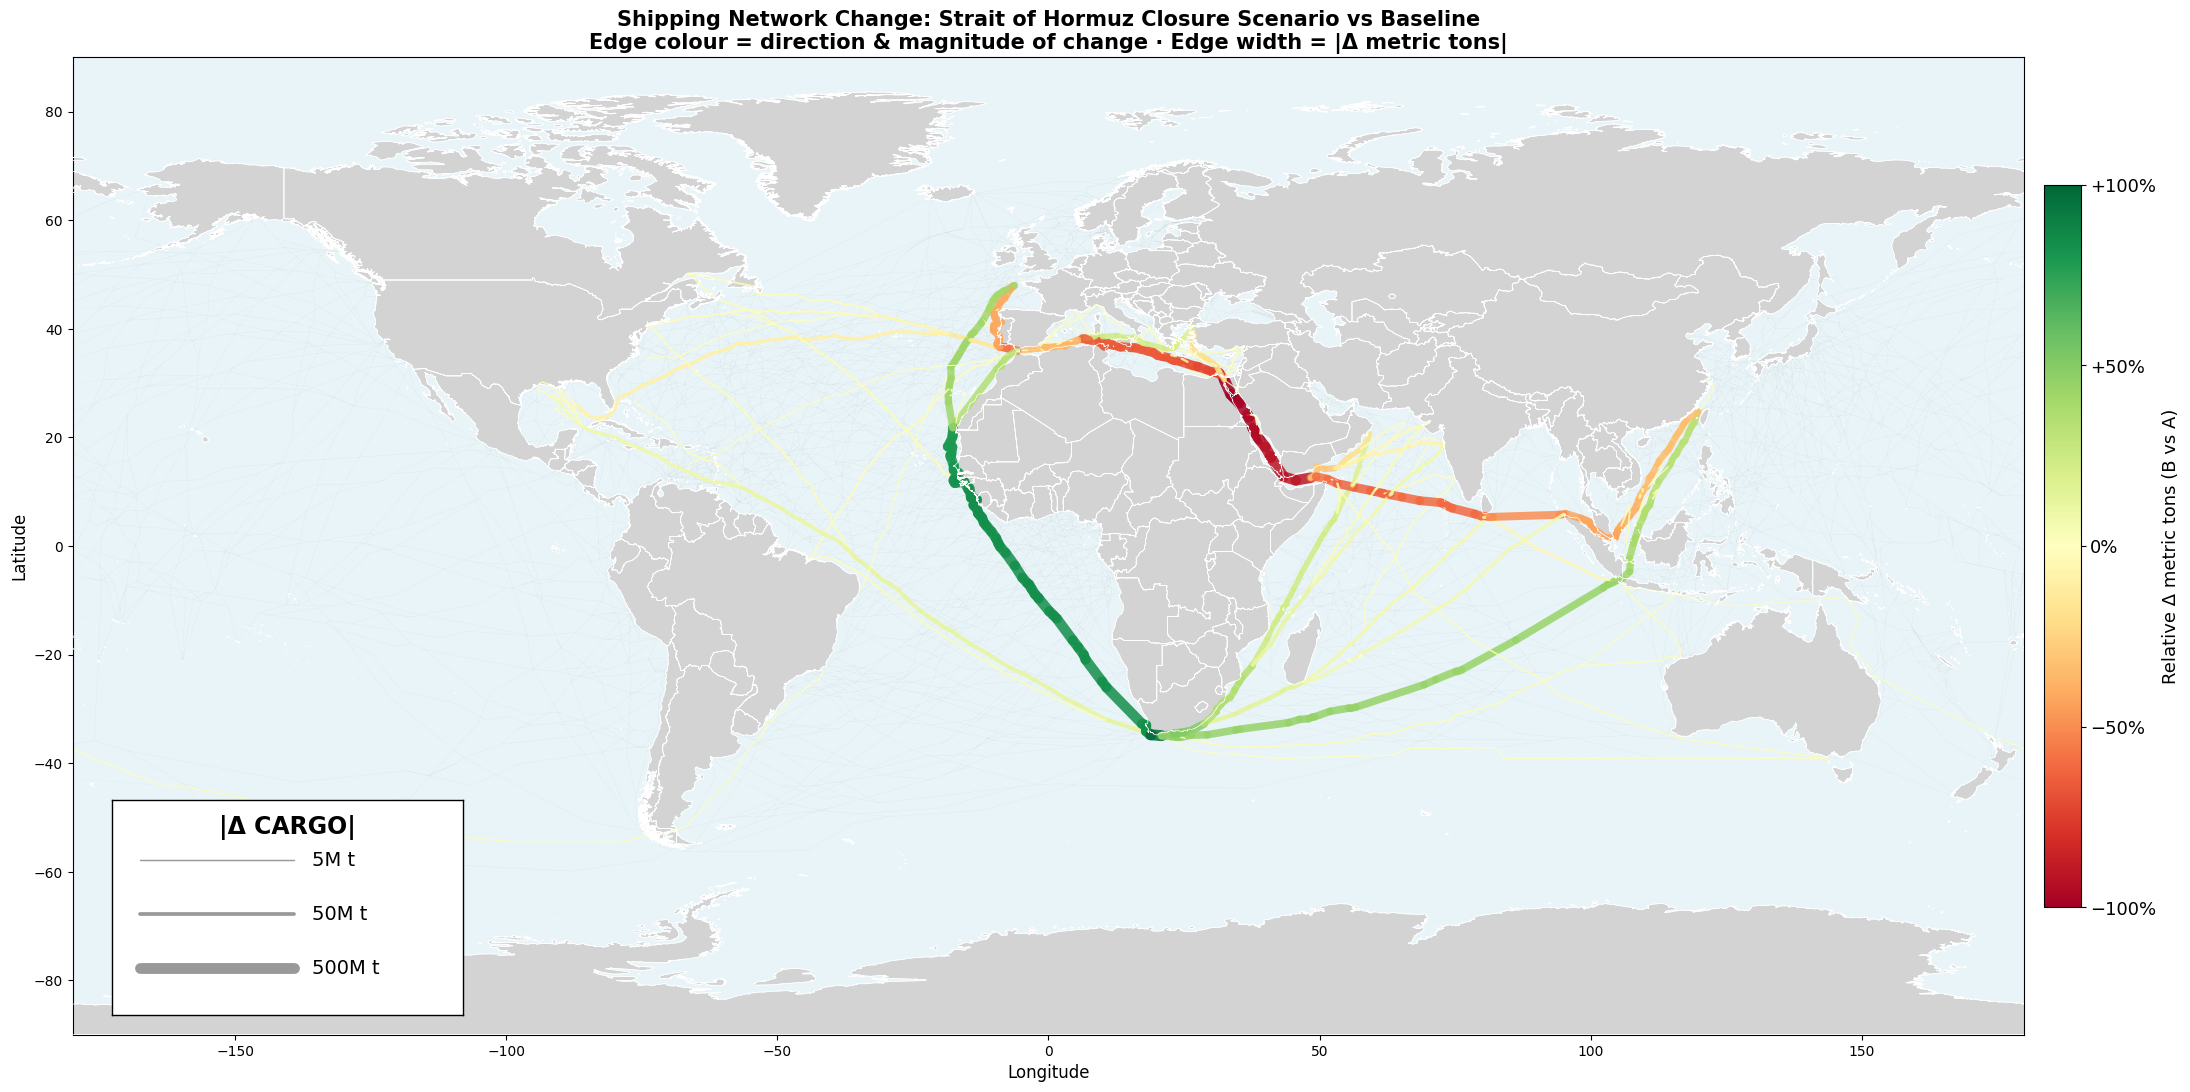

In [489]:
# ── 1. Network Comparison Map ─────────────────────────────────────────────────
# Edge colour = RdYlGn spectrum: dark red (large loss) → yellow (no change) → dark green (large gain).
# Edge width  ∝ |Δ cargo|; legend shows round reference values.
# All network edges drawn as faint background so the full topology is visible.

METRIC = 'weight'   # 'weight' (metric tons) or 'value' (USD)

col_a = 'weight_a' if METRIC == 'weight' else 'value_a'
col_b = 'weight_b' if METRIC == 'weight' else 'value_b'
metric_label = 'metric tons' if METRIC == 'weight' else 'USD'

# Build signed delta lookup keyed by canonical (min, max) node-string pair
edge_delta = {}
for _, row in edges.iterrows():
    edge_delta[(row['e0'], row['e1'])] = row[col_b] - row[col_a]

max_abs_delta = max((abs(v) for v in edge_delta.values()), default=1.0)
THRESHOLD = max_abs_delta * 0.005   # below 0.5% of max → treated as no change

MIN_EDGE_WIDTH = 0.3
MAX_EDGE_WIDTH = 8.0
COLOR_ZERO = '#bbbbbb'

# RdYlGn colourmap: maps signed ratio in [-1, 1] to colour
CMAP_EDGE = cm.RdYlGn
NORM_EDGE = mcolors.TwoSlopeNorm(vmin=-1.0, vcenter=0.0, vmax=1.0)

def _edge_color(delta):
    ratio = np.clip(delta / max_abs_delta, -1.0, 1.0)
    return CMAP_EDGE(NORM_EDGE(ratio))

def _draw_edge(ax, x1, y1, x2, y2, color, lw, alpha=0.9, zorder=1):
    dlon = x2 - x1
    if abs(dlon) > 180:
        if dlon > 0:
            frac = (-180 - x1) / (x2 - 360 - x1)
            y_b  = y1 + frac * (y2 - y1)
            ax.plot([x1, -180], [y1, y_b], color=color, linewidth=lw, alpha=alpha,
                    linestyle='--', zorder=zorder, solid_capstyle='round')
            ax.plot([180,  x2], [y_b, y2], color=color, linewidth=lw, alpha=alpha,
                    linestyle='--', zorder=zorder, solid_capstyle='round')
        else:
            frac = (180 - x1) / (x2 + 360 - x1)
            y_b  = y1 + frac * (y2 - y1)
            ax.plot([x1,  180], [y1, y_b], color=color, linewidth=lw, alpha=alpha,
                    linestyle='--', zorder=zorder, solid_capstyle='round')
            ax.plot([-180, x2], [y_b, y2], color=color, linewidth=lw, alpha=alpha,
                    linestyle='--', zorder=zorder, solid_capstyle='round')
    else:
        ax.plot([x1, x2], [y1, y2], color=color, linewidth=lw, alpha=alpha,
                zorder=zorder, solid_capstyle='round')

fig, ax = plt.subplots(figsize=(22, 12), dpi=100)
world.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.5)
ax.set_facecolor('#E8F4F8')
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)

# Pass 1: full network as faint gray background
for (u, v) in G.edges():
    xu, yu = pos.get(str(u), (None, None))
    xv, yv = pos.get(str(v), (None, None))
    if xu is None or xv is None:
        continue
    _draw_edge(ax, xu, yu, xv, yv, color=COLOR_ZERO, lw=0.2, alpha=0.25, zorder=0)

# Pass 2: edges with meaningful delta, coloured by signed ratio, width by |delta|
for (u, v) in G.edges():
    xu, yu = pos.get(str(u), (None, None))
    xv, yv = pos.get(str(v), (None, None))
    if xu is None or xv is None:
        continue
    e0, e1 = min(str(u), str(v)), max(str(u), str(v))
    delta = edge_delta.get((e0, e1), 0.0)
    if abs(delta) < THRESHOLD:
        continue
    color = _edge_color(delta)
    lw = MIN_EDGE_WIDTH + (MAX_EDGE_WIDTH - MIN_EDGE_WIDTH) * np.sqrt(abs(delta) / max_abs_delta)
    _draw_edge(ax, xu, yu, xv, yv, color=color, lw=lw, alpha=0.85, zorder=2)

# ── Country borders redrawn on top ──────────────────────────────────────────
world.boundary.plot(ax=ax, edgecolor='white', linewidth=0.5, zorder=3)

# ── Colourbar ────────────────────────────────────────────────────────────────
sm = cm.ScalarMappable(cmap=CMAP_EDGE, norm=NORM_EDGE)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.018, pad=0.01,
                    ticks=[-1, -0.5, 0, 0.5, 1])
cbar.ax.set_yticklabels(['−100%', '−50%', '0%', '+50%', '+100%'], fontsize=13)
cbar.set_label(f'Relative Δ {metric_label} (B vs A)', fontsize=13)

# ── Edge-width legend (inset, lower left) ────────────────────────────────────
# Pick three round reference values spaced across the magnitude range
import math as _math
_top_mag = 10 ** int(_math.floor(_math.log10(max_abs_delta)))
_top = round(max_abs_delta / _top_mag) * _top_mag
_ref_vals = [_top / 100, _top / 10, _top]

def _fmt_delta(val):
    if METRIC == 'weight':
        if val >= 1e9:  return f'{val/1e9:.4g}B t'
        if val >= 1e6:  return f'{val/1e6:.4g}M t'
        if val >= 1e3:  return f'{val/1e3:.4g}K t'
        return f'{val:.4g} t'
    else:
        if val >= 1e12: return f'${val/1e12:.4g}T'
        if val >= 1e9:  return f'${val/1e9:.4g}B'
        if val >= 1e6:  return f'${val/1e6:.4g}M'
        return f'${val:.4g}'

ax_leg = inset_axes(ax, width='18%', height='22%', loc='lower left',
                    bbox_to_anchor=(0.02, 0.02, 1, 1),
                    bbox_transform=ax.transAxes, borderpad=0)
ax_leg.set_xlim(0, 1); ax_leg.set_ylim(0, 1)
ax_leg.set_facecolor('white'); ax_leg.patch.set_alpha(1.0)
for spine in ax_leg.spines.values():
    spine.set_edgecolor('black'); spine.set_linewidth(1); spine.set_visible(True)
ax_leg.set_xticks([]); ax_leg.set_yticks([])
ax_leg.text(0.5, 0.93, '|Δ CARGO|', ha='center', va='top', fontsize=17, fontweight='bold')
for y_pos, ref_val in zip([0.72, 0.47, 0.22], _ref_vals):
    frac = min(ref_val / max_abs_delta, 1.0)
    lw_ref = MIN_EDGE_WIDTH + (MAX_EDGE_WIDTH - MIN_EDGE_WIDTH) * frac**0.5
    ax_leg.plot([0.08, 0.52], [y_pos, y_pos], color='gray',
                linewidth=lw_ref, alpha=0.8, solid_capstyle='round')
    ax_leg.text(0.57, y_pos, _fmt_delta(ref_val), va='center', fontsize=14)

ax.set_title(f'Shipping Network Change: {LABEL_B} vs {LABEL_A}\n'
             f'Edge colour = direction & magnitude of change · Edge width = |Δ {metric_label}|',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
plt.tight_layout()
plt.show()


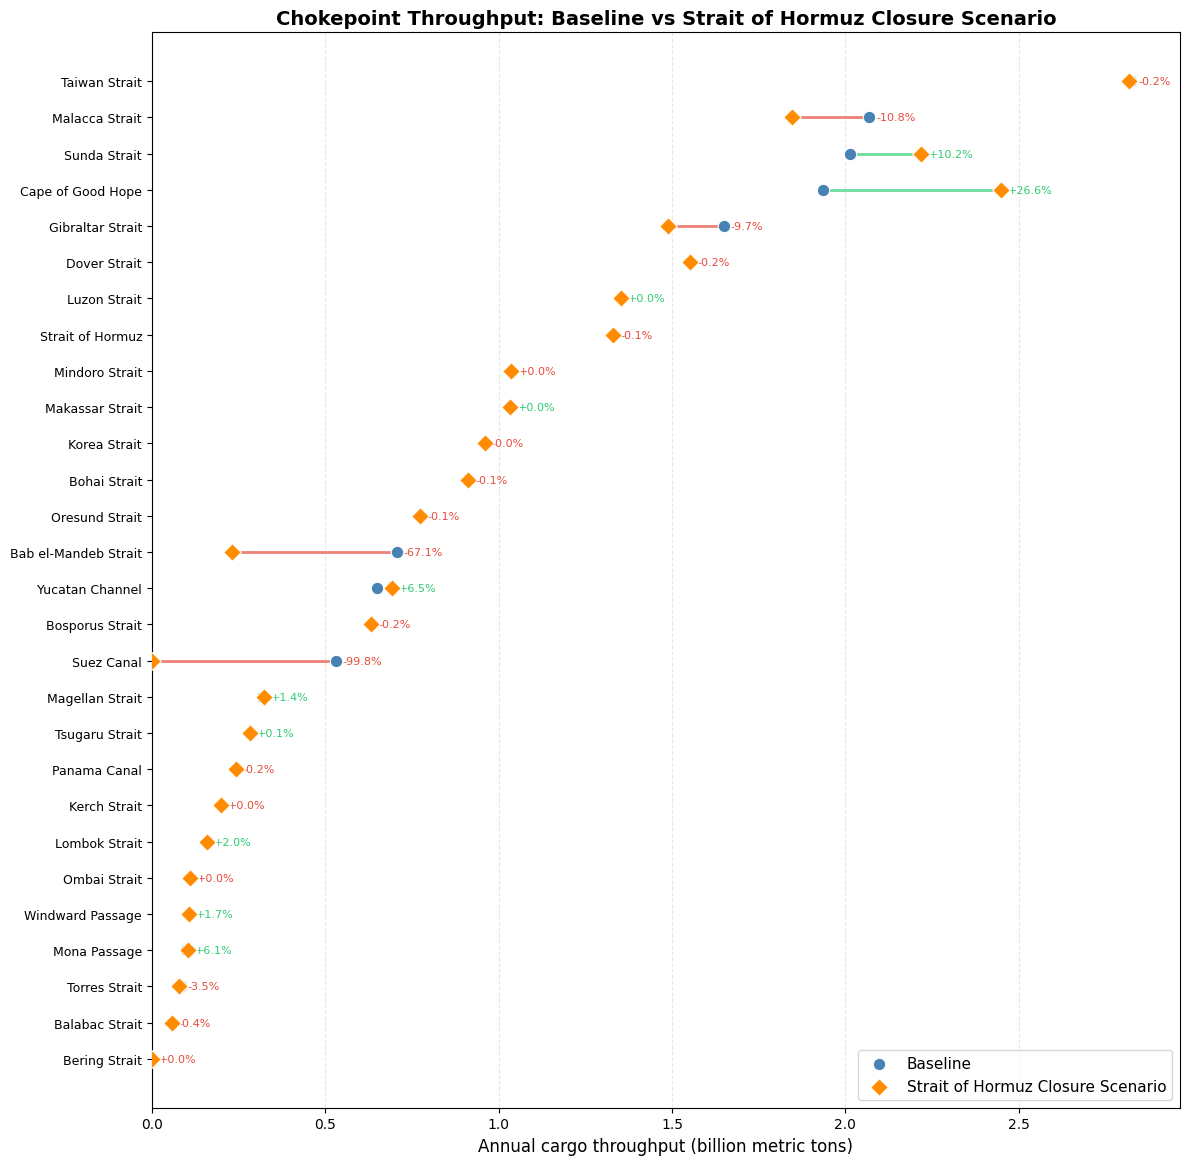


Chokepoint                       Baseline  Strait of Hormuz Closure Scenario      Change        Δ%
----------------------------------------------------------------------------
Taiwan Strait                       2.82B         2.82B       -0.00B    -0.2%
Malacca Strait                      2.07B         1.84B       -0.22B   -10.8%
Sunda Strait                        2.01B         2.22B       +0.21B  +  10.2%
Cape of Good Hope                   1.94B         2.45B       +0.51B  +  26.6%
Gibraltar Strait                    1.65B         1.49B       -0.16B    -9.7%
Dover Strait                        1.55B         1.55B       -0.00B    -0.2%
Luzon Strait                        1.35B         1.35B       +0.00B  +   0.0%
Strait of Hormuz                    1.33B         1.33B       -0.00B    -0.1%
Mindoro Strait                      1.04B         1.04B       +0.00B  +   0.0%
Makassar Strait                     1.03B         1.03B       +0.00B  +   0.0%
Korea Strait                        0.

In [490]:
# ── 2. Chokepoint Dumbbell Chart ──────────────────────────────────────────────
# Each chokepoint: two dots (A and B) connected by a coloured arrow.
# Sorted by scenario-A throughput descending.

choke = pd.merge(
    choke_a[['choke_name','cargo_total_weight']].rename(columns={'cargo_total_weight':'weight_a'}),
    choke_b[['choke_name','cargo_total_weight']].rename(columns={'cargo_total_weight':'weight_b'}),
    on='choke_name', how='outer'
).fillna(0).sort_values('weight_a', ascending=True)

choke['delta']    = choke['weight_b'] - choke['weight_a']
choke['pct']      = choke['delta'] / (choke['weight_a'] + 1e6) * 100
choke['color']    = choke['delta'].map(lambda d: '#2ecc71' if d > 0 else '#e74c3c')

fig, ax = plt.subplots(figsize=(12, max(7, len(choke) * 0.42)))
y_pos = np.arange(len(choke))

# Connecting line
for i, row in enumerate(choke.itertuples()):
    ax.plot([row.weight_a/1e9, row.weight_b/1e9], [i, i],
            color=row.color, lw=2.0, alpha=0.7, zorder=1)

# Dots
ax.scatter(choke['weight_a']/1e9, y_pos, color='steelblue', s=80,
           zorder=5, label=LABEL_A, edgecolors='white', linewidths=0.8)
ax.scatter(choke['weight_b']/1e9, y_pos, color='darkorange', s=80,
           zorder=5, label=LABEL_B, edgecolors='white', linewidths=0.8,
           marker='D')

# Delta annotations
for i, row in enumerate(choke.itertuples()):
    x_ann = max(row.weight_a, row.weight_b) / 1e9
    sign  = '+' if row.delta >= 0 else ''
    ax.text(x_ann + 0.02, i, f'{sign}{row.pct:.1f}%',
            va='center', fontsize=8, color=row.color)

ax.set_yticks(y_pos)
ax.set_yticklabels(choke['choke_name'], fontsize=9)
ax.set_xlabel('Annual cargo throughput (billion metric tons)', fontsize=12)
ax.set_title(f'Chokepoint Throughput: {LABEL_A} vs {LABEL_B}',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

# Print summary table
print(f'\n{"Chokepoint":<28} {LABEL_A:>12}  {LABEL_B:>12}  {"Change":>10}  {"Δ%":>8}')
print('-'*76)
for row in choke.sort_values('weight_a', ascending=False).itertuples():
    sign = '+' if row.delta >= 0 else ''
    print(f'{row.choke_name:<28} {row.weight_a/1e9:>11.2f}B  {row.weight_b/1e9:>11.2f}B  '
          f'{row.delta/1e9:>+10.2f}B  {sign}{row.pct:>6.1f}%')

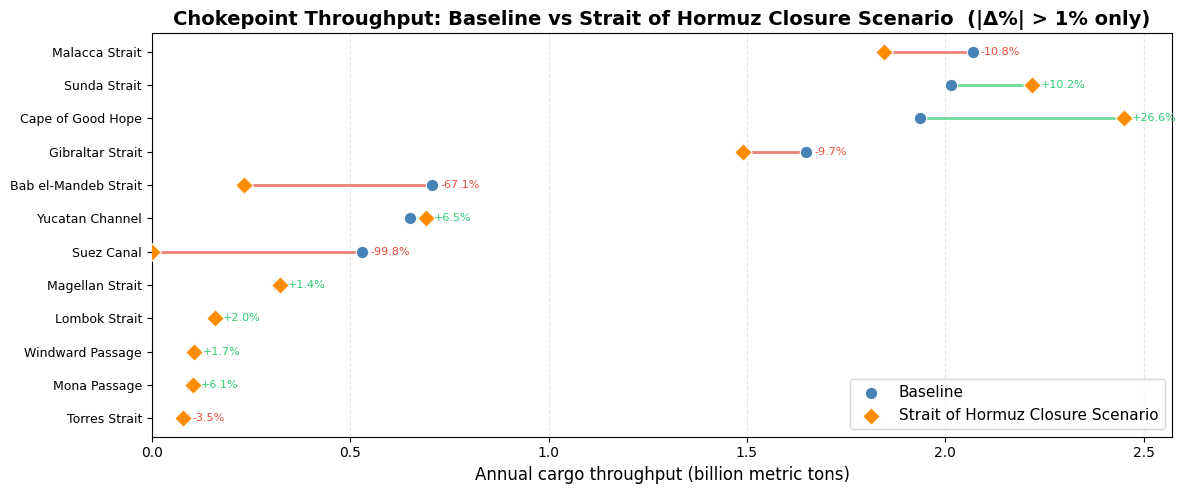

In [491]:
# ── 2b. Chokepoint Dumbbell Chart — significant changes only (|Δ%| > 1%) ────
choke_sig = choke[choke['pct'].abs() > 1].copy()

if choke_sig.empty:
    print('No chokepoints with |Δ%| > 1%')
else:
    fig, ax = plt.subplots(figsize=(12, max(4, len(choke_sig) * 0.42)))
    y_pos = np.arange(len(choke_sig))

    for i, row in enumerate(choke_sig.itertuples()):
        ax.plot([row.weight_a/1e9, row.weight_b/1e9], [i, i],
                color=row.color, lw=2.0, alpha=0.7, zorder=1)

    ax.scatter(choke_sig['weight_a']/1e9, y_pos, color='steelblue', s=80,
               zorder=5, label=LABEL_A, edgecolors='white', linewidths=0.8)
    ax.scatter(choke_sig['weight_b']/1e9, y_pos, color='darkorange', s=80,
               zorder=5, label=LABEL_B, edgecolors='white', linewidths=0.8,
               marker='D')

    for i, row in enumerate(choke_sig.itertuples()):
        x_ann = max(row.weight_a, row.weight_b) / 1e9
        sign  = '+' if row.delta >= 0 else ''
        ax.text(x_ann + 0.02, i, f'{sign}{row.pct:.1f}%',
                va='center', fontsize=8, color=row.color)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(choke_sig['choke_name'], fontsize=9)
    ax.set_xlabel('Annual cargo throughput (billion metric tons)', fontsize=12)
    ax.set_title(f'Chokepoint Throughput: {LABEL_A} vs {LABEL_B}  (|Δ%| > 1% only)',
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=11, loc='lower right')
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_xlim(left=0)
    plt.tight_layout()
    plt.show()


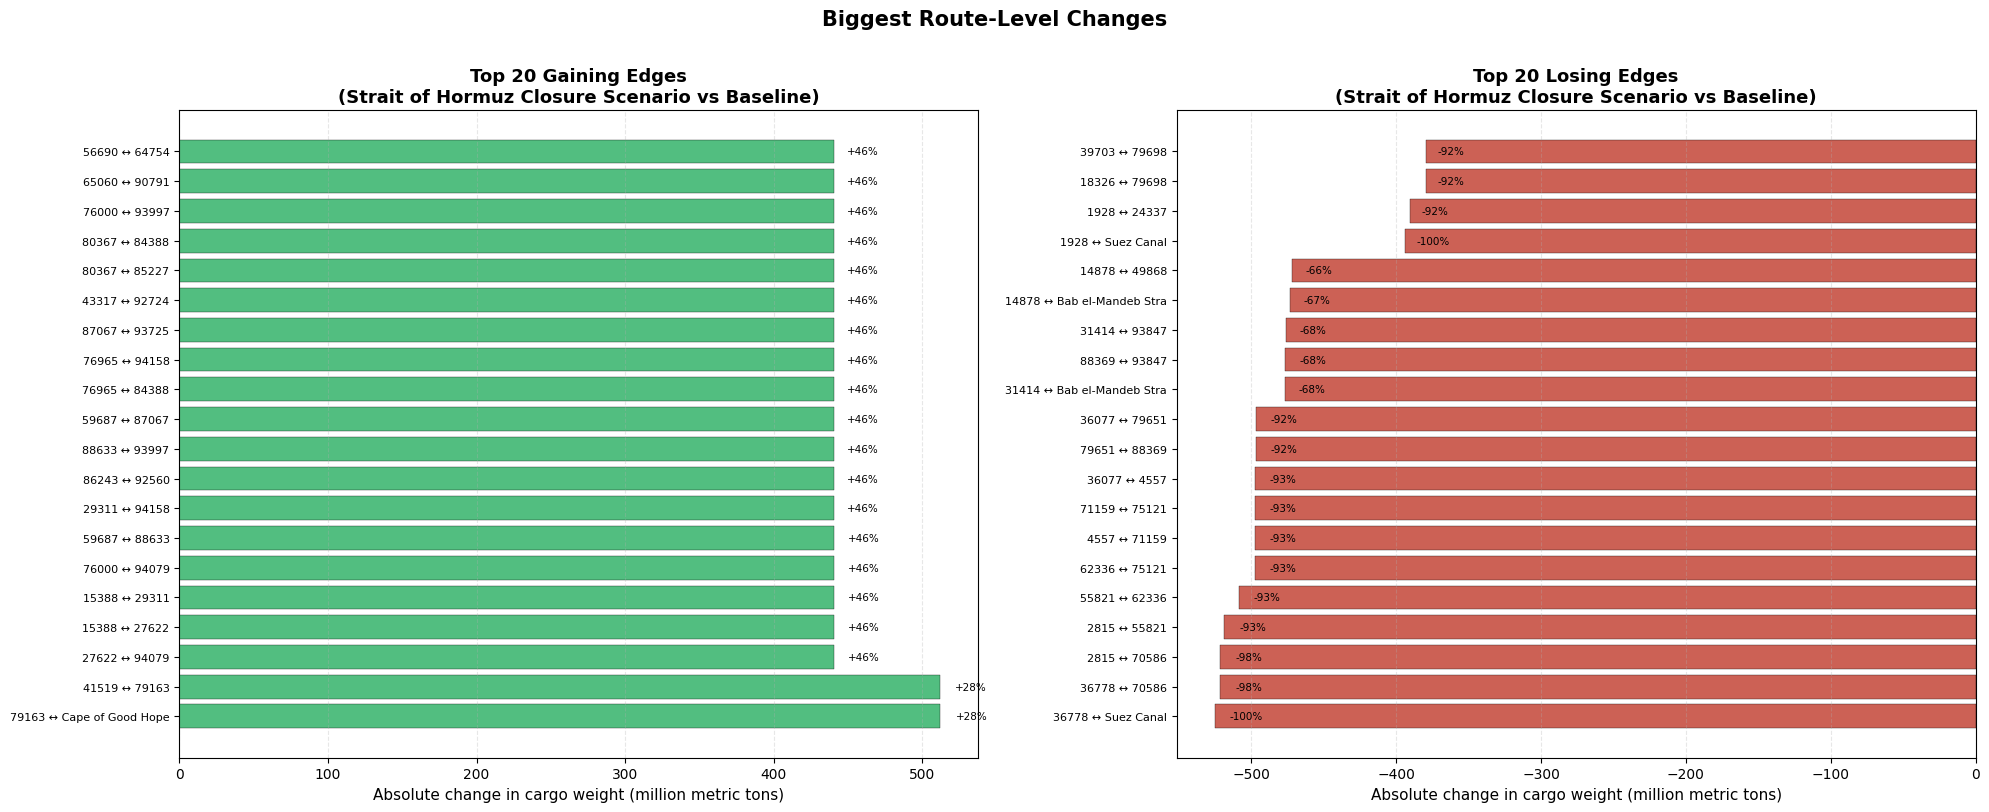

In [492]:
# ── 3. Top Edge Gainers & Losers ──────────────────────────────────────────────
# Only edges with meaningful traffic; labelled by nearest port name if available.

sig = active[active['ships_a'] >= MIN_SHIPS].copy()

# Build a lookup: node_id -> label (port name or choke name or node id)
node_label = {}
for n, d in G.nodes(data=True):
    if d.get('source') == 'port':
        node_label[n] = d.get('portname', str(n))
    elif d.get('source') == 'choke_point':
        node_label[n] = d.get('name', str(n))
    else:
        node_label[n] = str(n)

def edge_label(e0, e1):
    l0 = node_label.get(e0, str(e0))[:18]
    l1 = node_label.get(e1, str(e1))[:18]
    return f'{l0} ↔ {l1}'

sig['label'] = sig.apply(lambda r: edge_label(r['e0'], r['e1']), axis=1)
sig['pct_change'] = sig['rel_change'] * 100

gainers = sig.nlargest(TOP_EDGES_BAR, 'abs_change')
losers  = sig.nsmallest(TOP_EDGES_BAR, 'abs_change')

fig, (ax_g, ax_l) = plt.subplots(1, 2, figsize=(20, 8))

for ax, df, title, color in [
    (ax_g, gainers, f'Top {TOP_EDGES_BAR} Gaining Edges', '#27ae60'),
    (ax_l, losers,  f'Top {TOP_EDGES_BAR} Losing Edges',  '#c0392b'),
]:
    df = df.sort_values('abs_change', ascending=(color=='#c0392b'))
    y  = np.arange(len(df))
    bars = ax.barh(y, df['abs_change']/1e6, color=color, alpha=0.8,
                   edgecolor='black', linewidth=0.3)
    ax.set_yticks(y)
    ax.set_yticklabels(df['label'], fontsize=8)
    ax.set_xlabel('Absolute change in cargo weight (million metric tons)', fontsize=11)
    ax.set_title(f'{title}\n({LABEL_B} vs {LABEL_A})', fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    # Annotate % change
    for bar, (_, row) in zip(bars, df.iterrows()):
        w = bar.get_width()
        sign = '+' if row['pct_change'] >= 0 else ''
        ax.text(w + abs(w)*0.02, bar.get_y() + bar.get_height()/2,
                f'{sign}{row["pct_change"]:.0f}%', va='center', fontsize=7.5)

plt.suptitle('Biggest Route-Level Changes', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

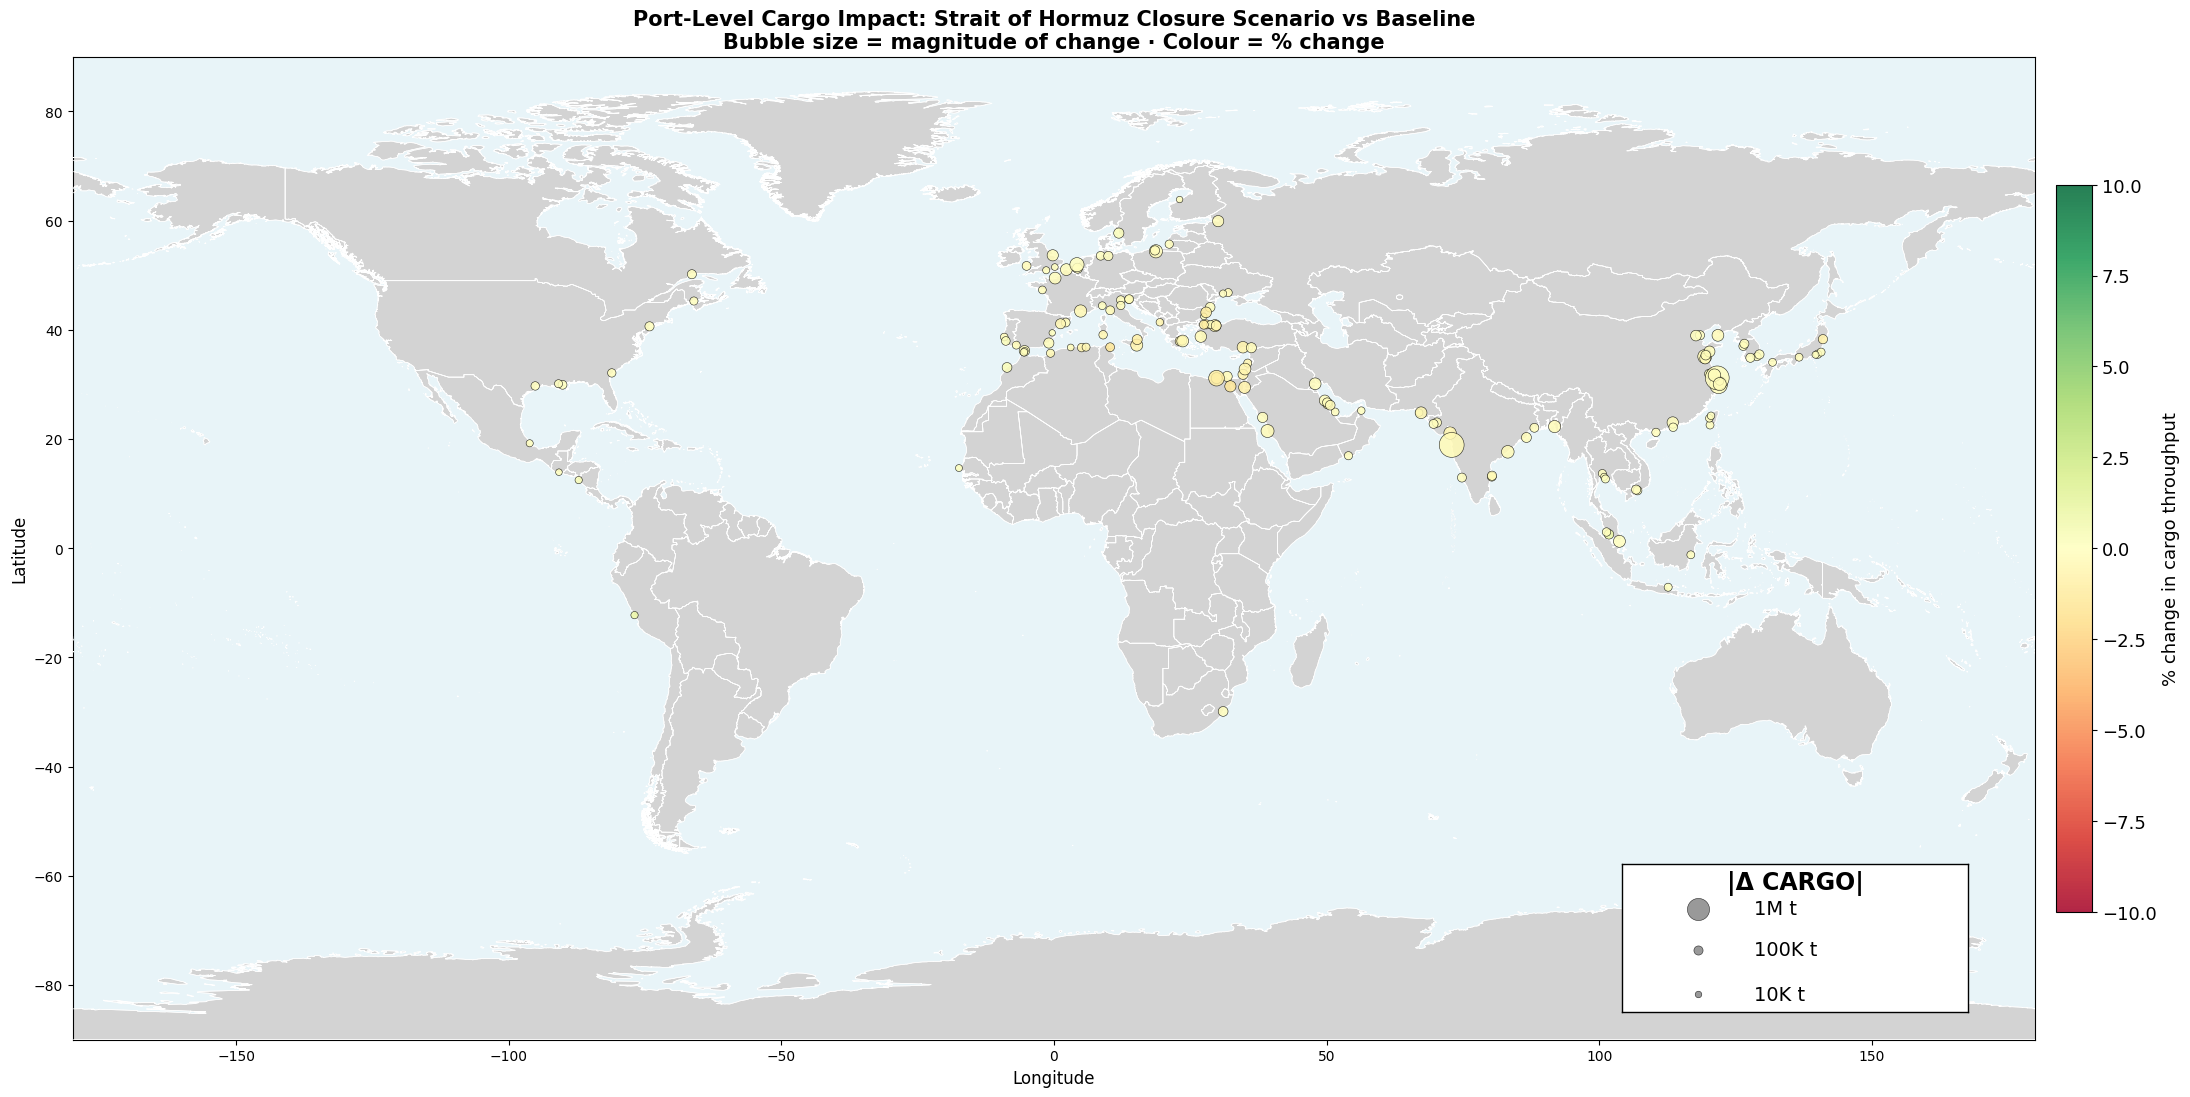

In [493]:
# ── 4. Port Impact Map ────────────────────────────────────────────────────────
# Bubble map: size = abs change in cargo, colour = % change (RdYlGn)

ports = pd.merge(
    port_a[['port_name','cargo_total_weight']].rename(columns={'cargo_total_weight':'weight_a'}),
    port_b[['port_name','cargo_total_weight']].rename(columns={'cargo_total_weight':'weight_b'}),
    on='port_name', how='outer'
).fillna(0)
ports['delta']    = ports['weight_b'] - ports['weight_a']
ports['pct']      = ports['delta'] / (ports['weight_a'] + 1e6) * 100

# Attach node lat/lon via port name
pname_to_latlon = {}
for n, d in G.nodes(data=True):
    if d.get('source') == 'port':
        pname_to_latlon[d.get('portname', '')] = (d['lon'], d['lat'])

ports['lon'] = ports['port_name'].map(lambda n: pname_to_latlon.get(n, (np.nan,np.nan))[0])
ports['lat'] = ports['port_name'].map(lambda n: pname_to_latlon.get(n, (np.nan,np.nan))[1])
ports = ports.dropna(subset=['lon','lat'])
max_abs_all = ports['delta'].abs().max()  # compute before filter
ports = ports[ports['delta'].abs() > max(1e3, max_abs_all * 0.001)]  # keep top 99.9% of range

fig, ax = plt.subplots(figsize=(22, 11), dpi=100)
world.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.5)
ax.set_facecolor('#E8F4F8')
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)

world.boundary.plot(ax=ax, edgecolor='white', linewidth=0.5, zorder=3)

MAX_ABS_PCT = max(ports['pct'].abs().quantile(0.95), 10)
norm_p   = mcolors.TwoSlopeNorm(vmin=-MAX_ABS_PCT, vcenter=0, vmax=MAX_ABS_PCT)
max_abs  = max_abs_all

sc = ax.scatter(
    ports['lon'], ports['lat'],
    s   = 20 + 300 * (ports['delta'].abs() / max_abs),
    c   = ports['pct'].clip(-MAX_ABS_PCT, MAX_ABS_PCT),
    cmap= cm.RdYlGn, norm=norm_p,
    edgecolors='black', linewidths=0.4, alpha=0.85, zorder=5
)

cbar = fig.colorbar(sc, ax=ax, orientation='vertical', fraction=0.018, pad=0.01)
cbar.ax.tick_params(labelsize=13)
cbar.set_label('% change in cargo throughput', fontsize=13)

# ── Size legend (bottom right inset, same algorithm as Simulation_Visualizations) ─
_cmax = float(max_abs)
_top_mag = 10 ** int(np.floor(np.log10(_cmax)))
_top = round(_cmax / _top_mag) * _top_mag      # round max to 1 sig fig
_ref_vals = [_top / 100, _top / 10, _top]

def _fmt_delta_mt(val):
    val = abs(val)
    if val >= 1e9: return f'{val/1e9:.4g}B t'
    if val >= 1e6: return f'{val/1e6:.4g}M t'
    if val >= 1e3: return f'{val/1e3:.4g}K t'
    return f'{val:.4g} t'

MIN_BUBBLE = 20
MAX_BUBBLE = 300
ax_bleg = inset_axes(ax, width='18%', height='15%', loc='lower right',
                     bbox_to_anchor=(0, 0, 0.98, 1),
                     bbox_transform=ax.transAxes, borderpad=2)
ax_bleg.set_xlim(0, 1); ax_bleg.set_ylim(0, 1)
ax_bleg.set_facecolor('white'); ax_bleg.patch.set_alpha(1.0)
for _spine in ax_bleg.spines.values():
    _spine.set_edgecolor('black'); _spine.set_linewidth(1); _spine.set_visible(True)
ax_bleg.set_xticks([]); ax_bleg.set_yticks([])
ax_bleg.text(0.5, 0.96, '|Δ CARGO|', ha='center', va='top', fontsize=17, fontweight='bold')
for _val, _y in zip(_ref_vals, [0.12, 0.42, 0.70]):
    _frac = min(_val / _cmax, 1.0)
    _s = MIN_BUBBLE + MAX_BUBBLE * _frac          # same formula as the map
    ax_bleg.scatter([0.22], [_y], s=_s, color='grey', alpha=0.8,
                    edgecolors='black', linewidths=0.4, zorder=2,
                    transform=ax_bleg.transData)
    ax_bleg.text(0.38, _y, _fmt_delta_mt(_val), va='center', fontsize=14)

ax.set_title(f'Port-Level Cargo Impact: {LABEL_B} vs {LABEL_A}\n'
             f'Bubble size = magnitude of change · Colour = % change',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
plt.tight_layout()
plt.show()

In [494]:
# ── Top 25 ports by absolute cargo change ────────────────────────────────────
top25 = (port_a.merge(port_b[['port_name','cargo_total_weight']], on='port_name', how='outer',
                      suffixes=('_a','_b'))
               .fillna(0)
               .assign(delta=lambda d: d['cargo_total_weight_b'] - d['cargo_total_weight_a'],
                       pct=lambda d: (d['cargo_total_weight_b'] - d['cargo_total_weight_a'])
                                     / (d['cargo_total_weight_a'] + 1e6) * 100)
               .reindex(columns=['port_name','cargo_total_weight_a','cargo_total_weight_b','delta','pct'])
               .rename(columns={'cargo_total_weight_a': LABEL_A, 'cargo_total_weight_b': LABEL_B})
               .assign(**{'|Δ| (M tons)': lambda d: d['delta'].abs() / 1e6,
                          'Δ%':           lambda d: d['pct']})
               .nlargest(25, '|Δ| (M tons)')
               .reset_index(drop=True))
top25.index += 1

def _fmt_mt(v):
    if abs(v) >= 1e3: return f'{v/1e3:+.1f}B t'
    return f'{v:+.1f}M t'

print(f'Top 25 ports by absolute cargo change ({LABEL_B} vs {LABEL_A})')
print(f'{"#":<4} {"Port":<30} {LABEL_A:>14} {LABEL_B:>14} {"Δ (M tons)":>12} {"Δ%":>8}')
print('-' * 90)
for rank, row in top25.iterrows():
    a_str = f'{row[LABEL_A]/1e9:.2f}B t'
    b_str = f'{row[LABEL_B]/1e9:.2f}B t'
    d_str = _fmt_mt(row['delta'] / 1e6)
    p_str = f'{row["Δ%"]:+.1f}%'
    print(f'{rank:<4} {row["port_name"]:<30} {a_str:>14} {b_str:>14} {d_str:>12} {p_str:>8}')


Top 25 ports by absolute cargo change (Strait of Hormuz Closure Scenario vs Baseline)
#    Port                                 Baseline Strait of Hormuz Closure Scenario   Δ (M tons)       Δ%
------------------------------------------------------------------------------------------
1    Mumbai-Jawaharlal Nehru (Nhava Sheva)        0.38B t        0.38B t      -1.3M t    -0.3%
2    Shanghai (Pudong)                     1.20B t        1.20B t      -1.2M t    -0.1%
3    Ningbo                                0.48B t        0.48B t      -0.6M t    -0.1%
4    El Dekheila                           0.04B t        0.04B t      -0.5M t    -1.1%
5    Rotterdam                             0.58B t        0.58B t      -0.4M t    -0.1%
6    Lanqiao Port                          0.11B t        0.11B t      -0.3M t    -0.3%
7    Gdansk                                0.15B t        0.15B t      -0.3M t    -0.2%
8    Zhoushan                              0.13B t        0.13B t      -0.3M t    -0.2%
9    

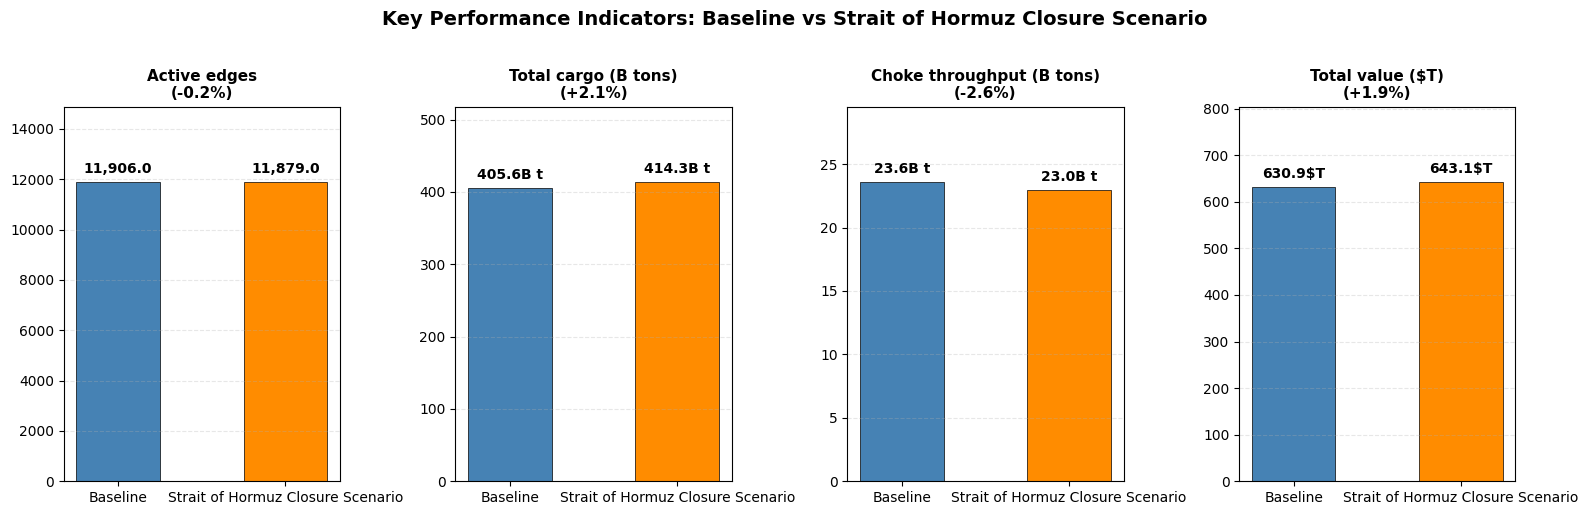

In [495]:
# ── 5. KPI Summary Bar Chart ──────────────────────────────────────────────────
# High-level comparison of total cargo, ships completed, route diversity.

# Aggregate totals from edge statistics
def kpis(edge_df, choke_df):
    active_edges = (edge_df['ship_count'] > 0).sum()
    total_weight = edge_df['cargo_total_weight'].sum() / 2  # each edge counted twice
    total_value  = edge_df['cargo_total_value'].sum()  / 2
    total_ships  = edge_df['ship_count'].max()  # approx; use choke or port for true count
    choke_weight = choke_df['cargo_total_weight'].sum()
    return dict(active_edges=active_edges, total_weight_B=total_weight,
                total_value_T=total_value/1e12, choke_weight_B=choke_weight/1e9)

k_a = kpis(edge_a, choke_a)
k_b = kpis(edge_b, choke_b)

metrics = [
    ('Active edges',              k_a['active_edges'],    k_b['active_edges'],    ''),
    ('Total cargo (B tons)',      k_a['total_weight_B']/1e9, k_b['total_weight_B']/1e9, 'B t'),
    ('Choke throughput (B tons)', k_a['choke_weight_B'],  k_b['choke_weight_B'],  'B t'),
    ('Total value ($T)',          k_a['total_value_T'],   k_b['total_value_T'],   '$T'),
]

fig, axes = plt.subplots(1, len(metrics), figsize=(16, 5))
for ax, (label, val_a, val_b, unit) in zip(axes, metrics):
    bars = ax.bar([LABEL_A, LABEL_B], [val_a, val_b],
                  color=['steelblue', 'darkorange'],
                  edgecolor='black', linewidth=0.5, width=0.5)
    for bar, val in zip(bars, [val_a, val_b]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
                f'{val:,.1f}{unit}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    delta_pct = (val_b - val_a) / (val_a + 1e-9) * 100
    sign = '+' if delta_pct >= 0 else ''
    ax.set_title(f'{label}\n({sign}{delta_pct:.1f}%)', fontsize=11, fontweight='bold')
    ax.set_ylim(0, max(val_a, val_b) * 1.25)
    ax.tick_params(labelsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle(f'Key Performance Indicators: {LABEL_A} vs {LABEL_B}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [496]:
# ── Queue & Occupancy — data loading (run once) ───────────────────────────────
ROLLING_DAYS    = 30
SCENARIO_COLORS = {LABEL_A: 'steelblue', LABEL_B: 'darkorange'}
scenarios       = {LABEL_A: DIR_A, LABEL_B: DIR_B}

# Build choke-node ID lookup for ALL choke points in the graph
ALL_CHOKE_NODES = {}
for _node in G.nodes():
    _attrs = G.nodes[_node]
    if _attrs.get('source') == 'choke_point':
        _name = _attrs.get('name') or ''
        if _name:
            ALL_CHOKE_NODES[_name] = str(_node)
print(f'Choke points found: {sorted(ALL_CHOKE_NODES)}')

# Load port occupancy for both scenarios
print('Loading port occupancy...')
port_occ = {}
for label, d in scenarios.items():
    df = pd.read_parquet(f'{d}/port_occupancy.parquet')
    df['occupancy'] = df['num_ships'] / df['capacity'].clip(lower=1)
    port_occ[label] = df
    print(f'  {label}: {len(df):,} rows')

# Load ship_locations once and pre-aggregate waiting counts per choke node
print('Loading ship locations for canal queue data...')
canal_data = {label: {} for label in scenarios}
for label, d in scenarios.items():
    table = pq.read_table(f'{d}/ship_locations.parquet',
                          columns=['status', 'node1', 'day'])
    df_loc = table.to_pandas()
    waiting = df_loc[df_loc['status'] == 'waiting_at_node']
    for canal_name, choke_node in ALL_CHOKE_NODES.items():
        wt = (waiting[waiting['node1'] == choke_node]
              .groupby('day').size().rename('waiting'))
        canal_data[label][canal_name] = wt
    print(f'  {label}: done')
print('Data loaded.')


Choke points found: ['Bab el-Mandeb Strait', 'Balabac Strait', 'Bering Strait', 'Bohai Strait', 'Bosporus Strait', 'Cape of Good Hope', 'Dover Strait', 'Gibraltar Strait', 'Kerch Strait', 'Korea Strait', 'Lombok Strait', 'Luzon Strait', 'Magellan Strait', 'Makassar Strait', 'Malacca Strait', 'Mindoro Strait', 'Mona Passage', 'Ombai Strait', 'Oresund Strait', 'Panama Canal', 'Strait of Hormuz', 'Suez Canal', 'Sunda Strait', 'Taiwan Strait', 'Torres Strait', 'Tsugaru Strait', 'Windward Passage', 'Yucatan Channel']
Loading port occupancy...
  Baseline: 3,216,592 rows
  Strait of Hormuz Closure Scenario: 3,215,064 rows
Loading ship locations for canal queue data...
  Baseline: done
  Strait of Hormuz Closure Scenario: done
Data loaded.


In [497]:
# ── plot_traffic(name, kind, rolling_days, shaded_periods) ───────────────────
# name           : port name (kind='occupancy') or choke point name (kind='queue')
# kind           : 'occupancy' — port berth occupancy % over time
#                  'queue'     — ships waiting at a canal/choke point over time
# rolling_days   : centered moving-average window in days (default: c)
#                  Uses center=True so the window is symmetric — no lag bias.
#                  min_periods=1 means edge days use a partial window rather than NaN.
# shaded_periods : list of (start_day, end_day, label) tuples that draw a grey
#                  vertical band across the plot, shown in the legend.
#                  E.g. [(58, 120, 'Strait of Hormuz closed')]

def plot_traffic(name, kind='occupancy', rolling_days=ROLLING_DAYS, shaded_periods=None):
    if kind not in ('occupancy', 'queue'):
        raise ValueError("kind must be 'occupancy' or 'queue'")

    fig, ax = plt.subplots(figsize=(16, 7))

    # ── Shaded periods (drawn first so they sit behind data lines) ────────────
    if shaded_periods:
        seen_labels = {}
        for (start, end, label) in shaded_periods:
            # Only pass label on the first span with that text to avoid duplicate
            # legend entries; subsequent spans with the same label are unlabelled.
            lbl = label if label not in seen_labels else '_nolegend_'
            ax.axvspan(start, end, alpha=0.35, color='dimgray', zorder=0, label=lbl)
            seen_labels[label] = True

    if kind == 'occupancy':
        found = False
        for label, df in port_occ.items():
            pdata = df[df['port_name'] == name]
            if pdata.empty:
                continue
            daily    = pdata.groupby('day')['occupancy'].mean()
            smoothed = daily.rolling(rolling_days, center=True, min_periods=1).mean()
            ax.plot(smoothed.index, smoothed.values * 100,
                    color=SCENARIO_COLORS[label], lw=1.5, label=label, alpha=0.9)
            found = True
        if not found:
            ax.text(0.5, 0.5, f'{name!r} not found in port occupancy data',
                    transform=ax.transAxes, ha='center', va='center',
                    color='gray', fontsize=12)
        ax.axhline(100, color='red', lw=2, linestyle='--', alpha=0.5, label='Full capacity')
        ax.set_ylabel('Occupancy %', fontsize=14)
        ax.set_title(f'{name} — Port Occupancy ({rolling_days}-day rolling avg)\n'
                     f'{LABEL_A} vs {LABEL_B}', fontsize=15, fontweight='bold')
        ax.set_ylim(0, None)
        ax.set_xlim(0, None)

    else:  # kind == 'queue'
        if name not in ALL_CHOKE_NODES:
            ax.text(0.5, 0.5, f'{name!r} not found in choke points.\n'
                    f'Available: {sorted(ALL_CHOKE_NODES)}',
                    transform=ax.transAxes, ha='center', va='center',
                    color='gray', fontsize=11, wrap=True)
        else:
            has_data = False
            for label, cdata in canal_data.items():
                wt = cdata.get(name, pd.Series(dtype=float))
                if wt.empty or wt.sum() == 0:
                    continue
                smoothed = wt.rolling(rolling_days, center=True, min_periods=1).mean()
                ax.plot(smoothed.index, smoothed.values,
                        color=SCENARIO_COLORS[label], lw=1.5, label=label, alpha=0.9)
                has_data = True
            if not has_data:
                ax.text(0.5, 0.5, f'No ships waiting at {name!r} in either scenario',
                        transform=ax.transAxes, ha='center', va='center',
                        color='gray', fontsize=12)
        ax.set_ylabel('Ships waiting in queue', fontsize=14)
        ax.set_title(f'{name} — Ships Waiting in Queue ({rolling_days}-day avg)\n'
                     f'{LABEL_A} vs {LABEL_B}', fontsize=15, fontweight='bold')
        ax.set_ylim(0, None)
        ax.set_xlim(0, None)

    ax.set_xlabel('Simulation Day', fontsize=14)
    legend_loc = 'lower right' if kind == 'occupancy' else 'upper right'
    ax.legend(fontsize=13, loc=legend_loc)
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


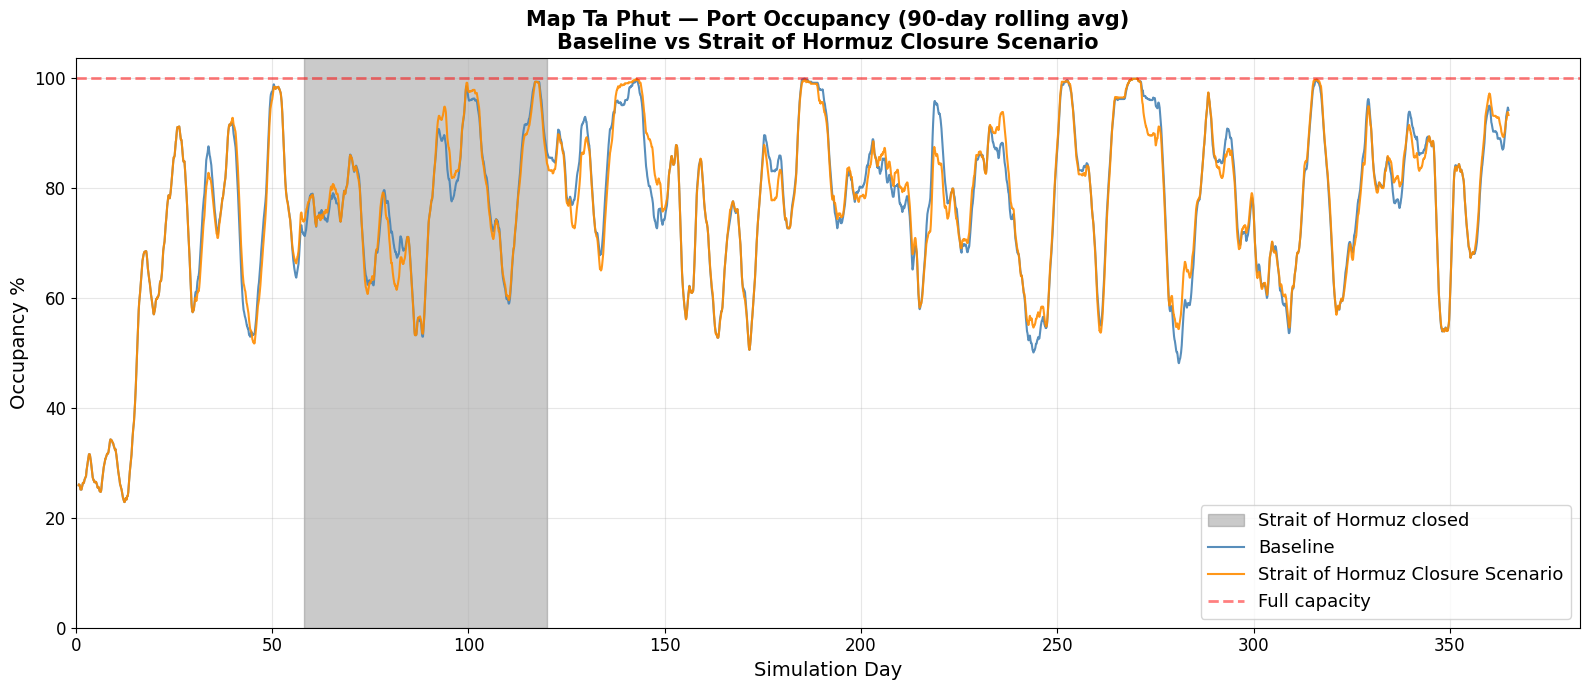

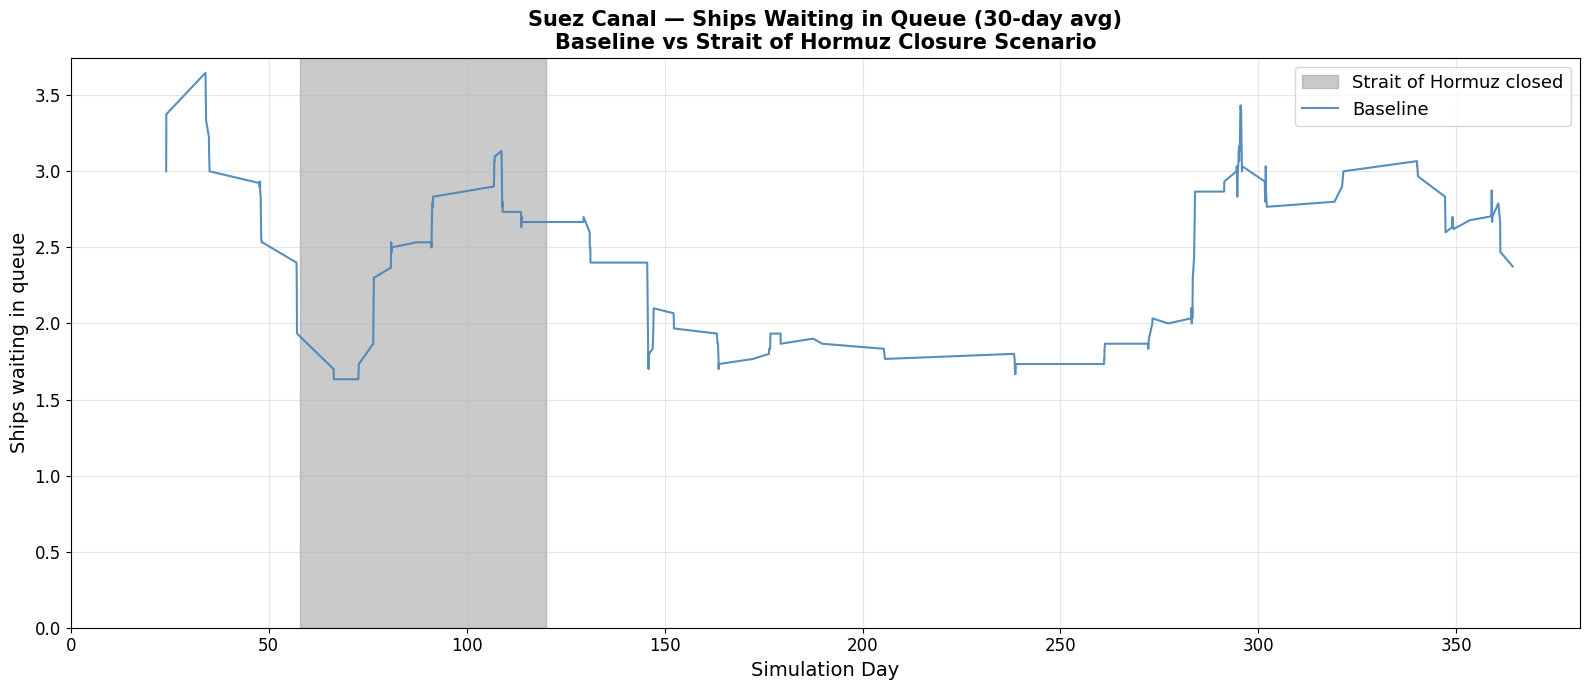

In [498]:
# ── Example calls ─────────────────────────────────────────────────────────────
HORMUZ_CLOSED = [(58, 120, 'Strait of Hormuz closed')]

plot_traffic('Map Ta Phut', kind='occupancy', shaded_periods=HORMUZ_CLOSED, rolling_days=90)
plot_traffic('Suez Canal',kind='queue',     shaded_periods=HORMUZ_CLOSED)


In [499]:
# ── Port & choke flow data loading (run once) ────────────────────────────────
# Port exports  : first 'loading'       event per ship → cargo leaves origin port
# Port imports  : first 'unloading'     event per ship → cargo arrives at dest port
# Canal transit : first 'canal_transit' event per ship → ship transits a canal
# Choke transit : first 'traveling'     event per ship on an edge touching a
#                 non-canal choke node  → ship passes through a regular chokepoint
# All derived in a single pass through ship_locations.parquet per scenario.

# Reverse lookup: choke node ID (str) → choke name
_node_to_choke = {v: k for k, v in ALL_CHOKE_NODES.items()}
# Separate canal names (use port_name field) from regular choke node IDs
_CANAL_NAMES   = set()
for _node in G.nodes():
    _a = G.nodes[_node]
    if _a.get('source') == 'choke_point' and _a.get('canal', False):
        _CANAL_NAMES.add(_a.get('name', ''))
# Fallback: treat any choke whose name contains 'Canal' as a canal
if not _CANAL_NAMES:
    _CANAL_NAMES = {n for n in ALL_CHOKE_NODES if 'Canal' in n}
_regular_choke_nodes = {nid for name, nid in ALL_CHOKE_NODES.items()
                        if name not in _CANAL_NAMES}
print(f'Canal choke points : {sorted(_CANAL_NAMES)}')
print(f'Regular choke nodes: {len(_regular_choke_nodes)}')

print('Loading port & choke flow data...')
port_exports  = {}
port_imports  = {}
choke_transit = {}   # choke_transit[label] = DataFrame(ship_id, choke_name, day, cargo_total_weight)

for label, d in scenarios.items():
    df_loc = pq.read_table(
        f'{d}/ship_locations.parquet',
        columns=['ship_id', 'status', 'port_name', 'node1', 'node2', 'day']
    ).to_pandas()

    # ── Port events ───────────────────────────────────────────────────────────
    port_events = df_loc[df_loc['status'].isin(['loading', 'unloading'])].copy()

    def first_port_events(df, stat):
        return (df[df['status'] == stat]
                .sort_values('day')
                .groupby(['ship_id', 'port_name'], as_index=False)
                .first()[['ship_id', 'port_name', 'day']])

    exp_raw = first_port_events(port_events, 'loading')
    imp_raw = first_port_events(port_events, 'unloading')

    # ── Canal transit events ──────────────────────────────────────────────────
    canal_ev = (df_loc[(df_loc['status'] == 'canal_transit') &
                       (df_loc['port_name'].isin(_CANAL_NAMES))]
                .sort_values('day')
                .groupby(['ship_id', 'port_name'], as_index=False)
                .first()[['ship_id', 'port_name', 'day']]
                .rename(columns={'port_name': 'choke_name'}))

    # ── Regular choke transit events ──────────────────────────────────────────
    # A ship is on an edge touching choke node X when node1==X or node2==X
    choke_rows = df_loc[
        (df_loc['status'] == 'traveling') &
        (df_loc['node1'].isin(_regular_choke_nodes) |
         df_loc['node2'].isin(_regular_choke_nodes))
    ].copy()
    # Assign choke name (prefer node1 match; fall back to node2)
    choke_rows['choke_name'] = choke_rows['node1'].map(_node_to_choke).fillna(
                                choke_rows['node2'].map(_node_to_choke))
    choke_rows = choke_rows.dropna(subset=['choke_name'])
    reg_ev = (choke_rows.sort_values('day')
              .groupby(['ship_id', 'choke_name'], as_index=False)
              .first()[['ship_id', 'choke_name', 'day']])

    del df_loc, port_events, choke_rows  # free memory

    # ── Join cargo weight ─────────────────────────────────────────────────────
    ships_df = pd.read_parquet(f'{d}/ships.parquet',
                               columns=['ship_id', 'cargo_total_weight'])

    port_exports[label]  = exp_raw.merge(ships_df, on='ship_id')
    port_imports[label]  = imp_raw.merge(ships_df, on='ship_id')
    choke_transit[label] = (pd.concat([canal_ev, reg_ev], ignore_index=True)
                              .merge(ships_df, on='ship_id'))

    print(f'  {label}: {len(port_exports[label]):,} export events, '
          f'{len(port_imports[label]):,} import events, '
          f'{len(choke_transit[label]):,} choke transit events')

print('Done.')


Canal choke points : ['Panama Canal', 'Suez Canal']
Regular choke nodes: 26
Loading port & choke flow data...
  Baseline: 226,276 export events, 216,065 import events, 13,487 choke transit events
  Strait of Hormuz Closure Scenario: 226,276 export events, 215,743 import events, 4,168 choke transit events
Done.


In [500]:
# ── plot_port_flow(port_name, kind, shaded_periods) ──────────────────────────
# port_name      : exact port name (case-sensitive)
# kind           : 'exports' — cumulative cargo loaded at this port over the year
#                  'imports' — cumulative cargo unloaded at this port over the year
# shaded_periods : list of (start_day, end_day, label) tuples for grey bands

def plot_port_flow(port_name, kind='exports', shaded_periods=None):
    if kind not in ('exports', 'imports'):
        raise ValueError("kind must be 'exports' or 'imports'")

    data_src = port_exports if kind == 'exports' else port_imports
    ylabel    = 'Cumulative cargo exported (metric tons)' if kind == 'exports'                 else 'Cumulative cargo imported (metric tons)'
    title_kind = 'Exports' if kind == 'exports' else 'Imports'

    fig, ax = plt.subplots(figsize=(16, 7))

    # ── Shaded periods ────────────────────────────────────────────────────────
    if shaded_periods:
        seen_labels = {}
        for (start, end, lbl) in shaded_periods:
            legend_lbl = lbl if lbl not in seen_labels else '_nolegend_'
            ax.axvspan(start, end, alpha=0.35, color='dimgray', zorder=0,
                       label=legend_lbl)
            seen_labels[lbl] = True

    found_any = False
    for label, df in data_src.items():
        port_df = df[df['port_name'] == port_name]
        if port_df.empty:
            continue
        daily = (port_df.groupby('day')['cargo_total_weight']
                        .sum()
                        .reindex(range(0, 366), fill_value=0))
        cumulative = daily.cumsum()
        ax.plot(cumulative.index, cumulative.values / 1e6,
                color=SCENARIO_COLORS[label], lw=2, label=label, alpha=0.9)
        found_any = True

    if not found_any:
        ax.text(0.5, 0.5, f'{port_name!r} not found in port flow data',
                transform=ax.transAxes, ha='center', va='center',
                color='gray', fontsize=12)

    ax.set_xlabel('Simulation Day', fontsize=14)
    ax.set_ylabel(ylabel + ' (millions)', fontsize=14)
    ax.set_title(f'{port_name} — Cumulative {title_kind}\n'
                 f'{LABEL_A} vs {LABEL_B}', fontsize=15, fontweight='bold')
    ax.set_xlim(0, 365)
    ax.set_ylim(0, None)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=13, loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [501]:
# ── plot_choke_flow(choke_name, shaded_periods) ───────────────────────────────
# choke_name     : exact choke point name, e.g. 'Suez Canal', 'Strait of Hormuz'
#                  Run the data loading cell to print available names.
# shaded_periods : list of (start_day, end_day, label) tuples for grey bands

def plot_choke_flow(choke_name, shaded_periods=None):
    fig, ax = plt.subplots(figsize=(16, 7))

    # ── Shaded periods ────────────────────────────────────────────────────────
    if shaded_periods:
        seen_labels = {}
        for (start, end, lbl) in shaded_periods:
            legend_lbl = lbl if lbl not in seen_labels else '_nolegend_'
            ax.axvspan(start, end, alpha=0.35, color='dimgray', zorder=0,
                       label=legend_lbl)
            seen_labels[lbl] = True

    found_any = False
    for label, df in choke_transit.items():
        choke_df = df[df['choke_name'] == choke_name]
        if choke_df.empty:
            continue
        daily = (choke_df.groupby('day')['cargo_total_weight']
                         .sum()
                         .reindex(range(0, 366), fill_value=0))
        cumulative = daily.cumsum()
        ax.plot(cumulative.index, cumulative.values / 1e6,
                color=SCENARIO_COLORS[label], lw=2, label=label, alpha=0.9)
        found_any = True

    if not found_any:
        available = sorted(set().union(*[set(df['choke_name']) for df in choke_transit.values()]))
        ax.text(0.5, 0.5,
                f'{choke_name!r} not found.\nAvailable: {available}',
                transform=ax.transAxes, ha='center', va='center',
                color='gray', fontsize=11)

    ax.set_xlabel('Simulation Day', fontsize=14)
    ax.set_ylabel('Cumulative cargo throughput (million metric tons)', fontsize=14)
    ax.set_title(f'{choke_name} — Cumulative Cargo Throughput\n'
                 f'{LABEL_A} vs {LABEL_B}', fontsize=15, fontweight='bold')
    ax.set_xlim(0, 365)
    ax.set_ylim(0, None)
    ax.tick_params(axis='both', labelsize=12)
    ax.legend(fontsize=13, loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


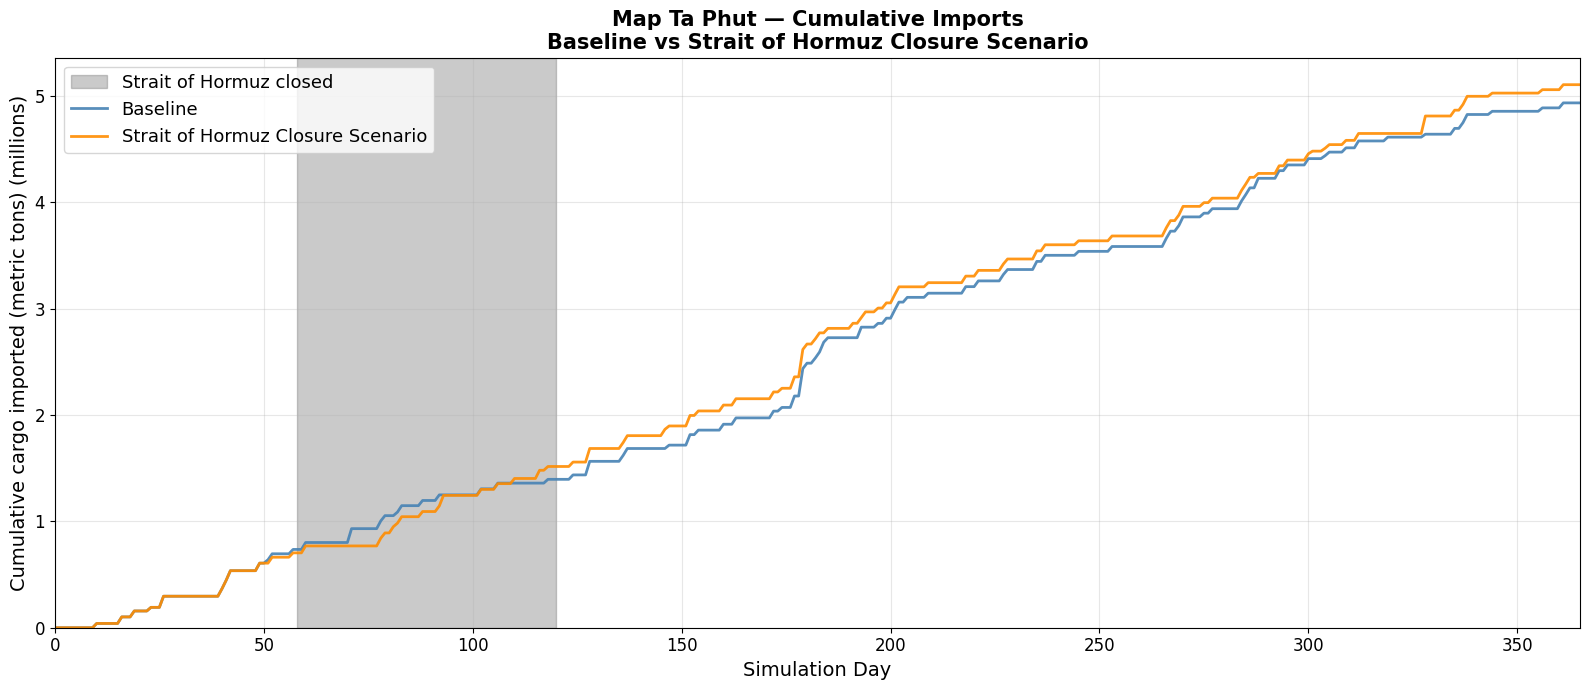

In [502]:
plot_port_flow('Map Ta Phut', kind='imports', shaded_periods=HORMUZ_CLOSED)

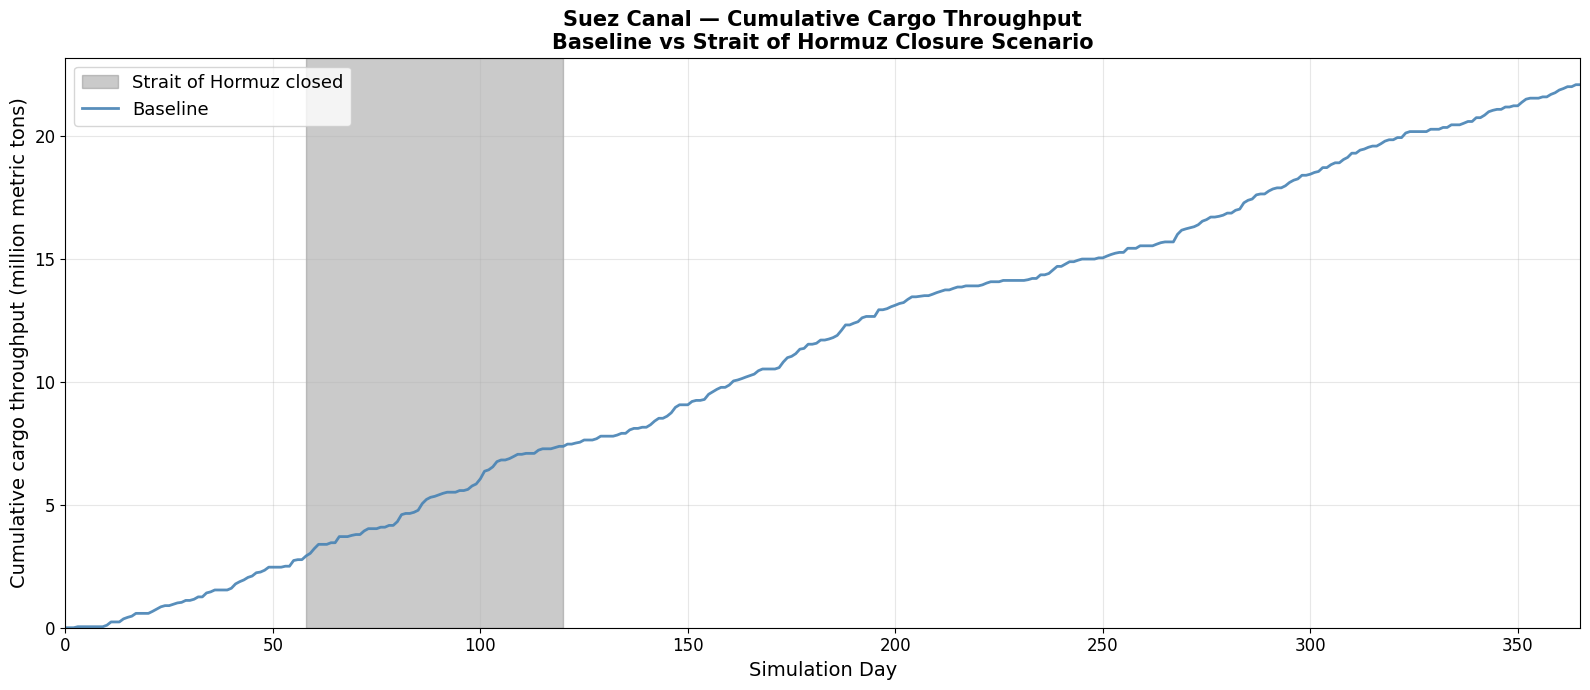

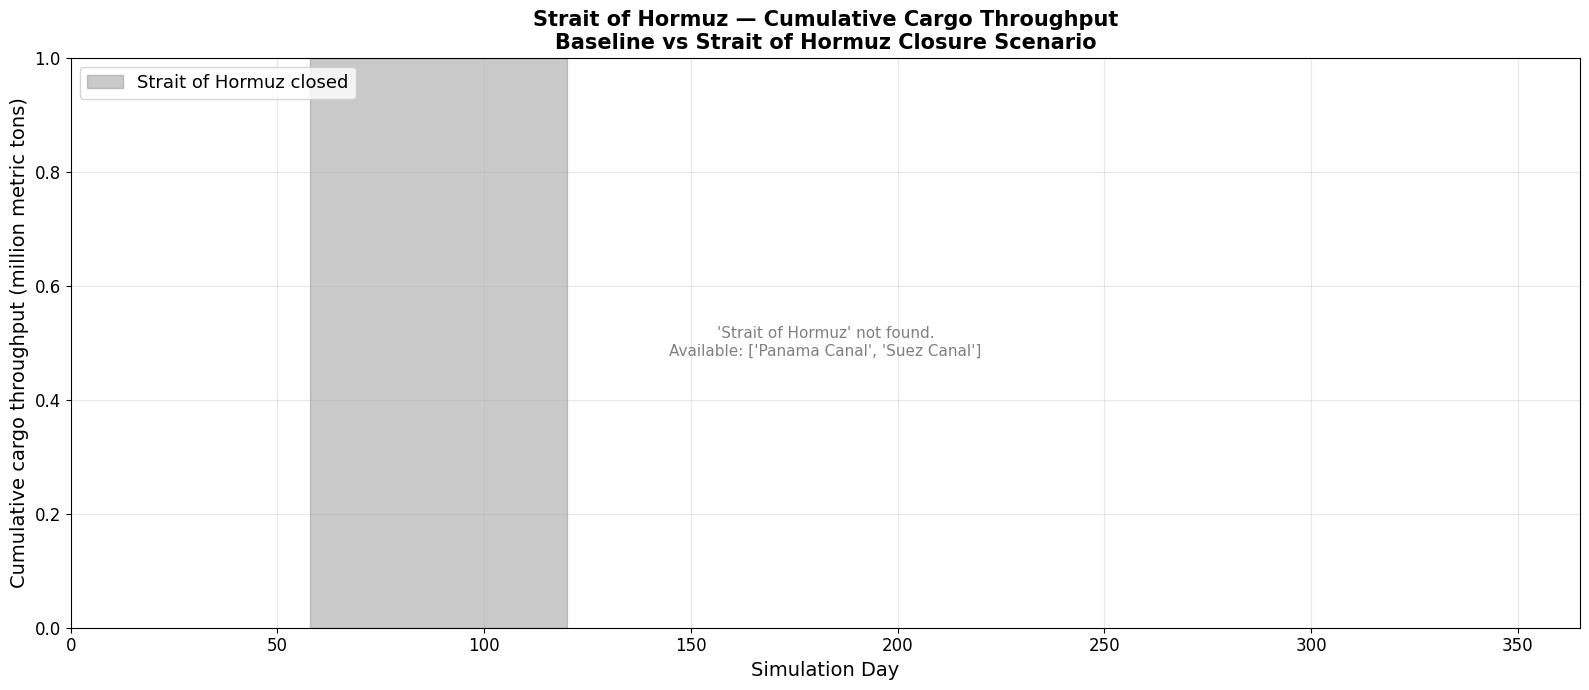

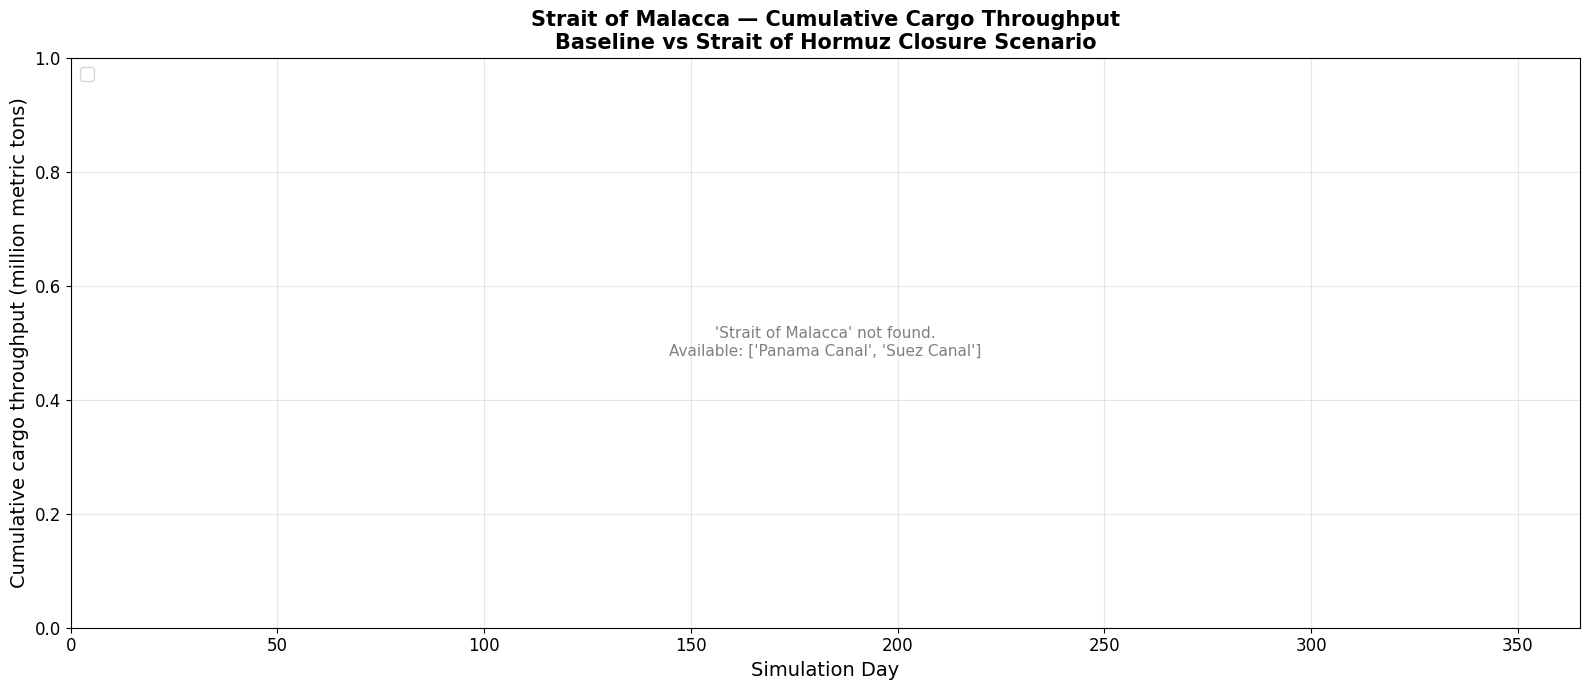

In [503]:
plot_choke_flow('Suez Canal',          shaded_periods=HORMUZ_CLOSED)
plot_choke_flow('Strait of Hormuz',    shaded_periods=HORMUZ_CLOSED)
plot_choke_flow('Strait of Malacca')